# **Rolling Stock ETL**

### Data Fetching

In [1]:
import pandas as pd
import psycopg2

def fetch_table_to_dataframe(host_ip, database_name, user, password, table_name, port=5432):
    """
    Connects to PostgreSQL and loads the given table into a Pandas DataFrame.
    """
    try:
        # Connect to PostgreSQL
        connection = psycopg2.connect(
            host=host_ip,
            database=database_name,
            user=user,
            password=password,
            port=port
        )
        print(f"Connected successfully to {database_name} on {host_ip}")

        # Create query
        query = f"SELECT * FROM {table_name};"

        # Load into pandas DataFrame
        df = pd.read_sql_query(query, connection)
        print(f"✅ Fetched {len(df)} rows from '{table_name}'")

        return df

    except Exception as e:
        print(f"❌ Error: {e}")
        return None

    finally:
        if connection:
            connection.close()

# --- Configuration (same as before) ---
HOST_IP = "100.95.110.69"
DATABASE_NAME = "pradigma-extractor"
USER = "postgres"
PASSWORD = "password"
PORT = 5432
TABLE_NAME = "extraction"

df_original = fetch_table_to_dataframe(HOST_IP, DATABASE_NAME, USER, PASSWORD, TABLE_NAME, PORT)

✅ Fetched 6834 rows from 'extraction'


In [2]:
df = df_original.copy(deep=True)
# df = df[(df['status_id'] == 1) & (df['dept_name'] == 'Rolling-Stock')][['filename', 'workorder_id', 'json_data']]
df = df[(df['dept_name'] == 'Rolling-Stock')][['filename', 'workorder_id', 'json_data']]

df.head(3)

,filename,workorder_id,json_data
0,RS_PM_WEK_4000586856.pdf,4.000587e+09,{'notification': {'notification_no': '12244350...
1,RS_PM_MTH_4000464193.pdf,4.000464e+09,{'notification': {'notification_no': '11945789...
3,RS_PM_MTH_4000446287.pdf,4.000446e+09,{'notification': {'notification_no': '11898977...


In [3]:
len(df)

1224

In [4]:
import pandas as pd

valid_json = df['json_data']
valid_json = valid_json[valid_json.apply(lambda x: isinstance(x, dict))]

all_keys = set()
for item in valid_json:
    all_keys.update(item.keys())

print(sorted(all_keys))

['air_standup', 'airbag-pressure', 'airbag_pressure', 'approval', 'cardan_shaft', 'cceb', 'greasing_cardan_shaft', 'notification', 'stamping', 'technician', 'train_startup_test', 'tyre-pressure', 'tyre-wear', 'tyre_pressure', 'tyre_wear', 'water_ponding', 'work_order']


In [5]:
rename_map = {
    'tyre-pressure': 'tyre_pressure'
}

df = df.copy(deep=True)
df['json_data'] = df['json_data'].apply(
    lambda data: {rename_map.get(k, k): v for k, v in data.items()} if isinstance(data, dict) else data
)


### Tyre Pressure

In [6]:
df['tyre_pressure'] = df['json_data'].apply(
    lambda x: x.get('tyre_pressure') if isinstance(x, dict) else None
)

df['workorder_id'] = (
    df['workorder_id']
    .apply(lambda x: int(x) if pd.notnull(x) else None)
)

df[['filename', 'workorder_id', 'tyre_pressure']].head(1).to_dict(orient='records')

[{'filename': 'RS_PM_WEK_4000586856.pdf',
  'workorder_id': 4000586856,
  'tyre_pressure': {'eca1': {'bogie1': {'bogie_sn': 'NA',
     'top_guide_wheel': {'a': {'before': 9.9, 'after': 9.9},
      'b': {'before': 11.2, 'after': 11.2},
      'c': {'before': 9.6, 'after': 9.6}},
     'load_wheel': {'before': 11, 'after': 11},
     'bottom_guide_wheel': {'a': {'before': 11.3, 'after': 11.3},
      'b': {'before': 11.1, 'after': 11.1},
      'c': {'before': 10.1, 'after': 10.1}}},
    'bogie2': {'bogie_sn': 'NA',
     'top_guide_wheel': {'a': {'before': 9.9, 'after': 9.9},
      'b': {'before': 11.4, 'after': 11.4},
      'c': {'before': 10.4, 'after': 10.4}},
     'load_wheel': {'before': 11, 'after': 11},
     'bottom_guide_wheel': {'a': {'before': 9.9, 'after': 9.9},
      'b': {'before': 9.7, 'after': 9.7},
      'c': {'before': 9.5, 'after': 9.5}}}},
   'ica2': {'bogie1': {'bogie_sn': 'NA',
     'top_guide_wheel': {'a': {'before': 10.9, 'after': 10.9},
      'b': {'before': 10.8, 'aft

In [7]:
import pandas as pd
import numpy as np

na_like_values = ['NA' 'NULL', 'NONE', 'NAN']

def is_na_like(val):
    if isinstance(val, (list, dict, np.ndarray)):
        return False
    try:
        if pd.isna(val):
            return True
    except Exception:
        pass
    val_str = str(val).strip().upper()
    return val_str in na_like_values

def find_na_keys(d):
    if not isinstance(d, dict):
        return []
    return [k for k, v in d.items() if is_na_like(v)]

df['na_keys'] = df['tyre_pressure'].apply(find_na_keys)

df_with_na = df[df['na_keys'].apply(lambda x: len(x) > 0)]

df_with_na[['filename', 'workorder_id', 'na_keys']].head(5)

,filename,workorder_id,na_keys


In [8]:
from collections import Counter

na_counter = Counter(k for keys in df['na_keys'] for k in keys)
na_summary = pd.DataFrame(na_counter.items(), columns=['key', 'na_count']).sort_values('na_count', ascending=False)

print(na_summary)

Empty DataFrame
Columns: [key, na_count]
Index: []


In [9]:

import numpy as np
import re
import pandas as pd

pattern = re.compile(r'^\s*(NA|NULL|NaN)\s*$', re.IGNORECASE)

def clean_value(val):
    """Clean individual values (string, dict, etc.)."""
    if isinstance(val, str):
        return '' if pattern.match(val) else val
    elif isinstance(val, dict):
        return {k: clean_value(v) for k, v in val.items()}
    elif isinstance(val, list):
        return [clean_value(v) for v in val]
    else:
        return '' if pd.isna(val) else val

df['tyre_pressure'] = df['tyre_pressure'].apply(clean_value)

df['tyre_pressure'] = df['tyre_pressure'].replace(np.nan, '', regex=True)

df['tyre_pressure'].head(3)

0    {'eca1': {'bogie1': {'bogie_sn': '', 'top_guid...
1    {'eca1': {'bogie1': {'bogie_sn': '231', 'top_g...
3    {'eca1': {'bogie1': {'bogie_sn': '257', 'top_g...
Name: tyre_pressure, dtype: object

In [10]:
def extract_leaf_keys(d, parent=''):
    keys = []
    if isinstance(d, dict):
        for k, v in d.items():
            full_key = f"{parent}.{k}" if parent else k
            if isinstance(v, dict):
                keys.extend(extract_leaf_keys(v, full_key))
            else:
                keys.append(full_key)
    return keys

# Extract leaf keys for each row
df['tyre_pressure_leaf_keys'] = df['tyre_pressure'].apply(
    lambda x: extract_leaf_keys(x) if isinstance(x, dict) else []
)

# Combine and deduplicate all keys across the entire DataFrame
unique_keys = sorted(set(k for sublist in df['tyre_pressure_leaf_keys'] for k in sublist))

# Print all unique keys
for k in unique_keys:
    print(k)


approval.date
approval.supervisor_id
approval.technician_id
eca1.bogie1.bogie_sn
eca1.bogie1.bottom_guide_wheel.a.after
eca1.bogie1.bottom_guide_wheel.a.before
eca1.bogie1.bottom_guide_wheel.b.after
eca1.bogie1.bottom_guide_wheel.b.before
eca1.bogie1.bottom_guide_wheel.c.after
eca1.bogie1.bottom_guide_wheel.c.before
eca1.bogie1.load_wheel.after
eca1.bogie1.load_wheel.before
eca1.bogie1.top_guide_wheel.a.after
eca1.bogie1.top_guide_wheel.a.before
eca1.bogie1.top_guide_wheel.b.after
eca1.bogie1.top_guide_wheel.b.before
eca1.bogie1.top_guide_wheel.c.after
eca1.bogie1.top_guide_wheel.c.before
eca1.bogie2.bogie_sn
eca1.bogie2.bottom_guide_wheel.a.after
eca1.bogie2.bottom_guide_wheel.a.before
eca1.bogie2.bottom_guide_wheel.b.after
eca1.bogie2.bottom_guide_wheel.b.before
eca1.bogie2.bottom_guide_wheel.c.after
eca1.bogie2.bottom_guide_wheel.c.before
eca1.bogie2.load_wheel.after
eca1.bogie2.load_wheel.before
eca1.bogie2.top_guide_wheel.a.after
eca1.bogie2.top_guide_wheel.a.before
eca1.bogie2.to

In [11]:
import json
import pandas as pd

def flatten_with_descriptions(row):
    flat = {}

    def recurse(subdict, parent=''):
        # Skip if None or not a dict or string
        if subdict is None:
            return

        # If it's a JSON string, parse it
        if isinstance(subdict, str):
            try:
                subdict = json.loads(subdict)
            except json.JSONDecodeError:
                return

        # If still not a dict, skip
        if not isinstance(subdict, dict):
            return

        for k, v in subdict.items():
            # if len(k) == 1 and k.isalpha():
            #     new_parent = parent
            # else:
            new_parent = f"{parent}.{k}" if parent else k

            if isinstance(v, dict):
                desc = v.get('description')
                if desc:
                    desc_key = (
                        desc.lower()
                        .replace(' ', '_')
                        .replace('/', '_')
                        .replace('&', 'and')
                    )
                    for sub_k, sub_v in v.items():
                        if sub_k != 'description':
                            flat[f"{new_parent}.{desc_key}.{sub_k}"] = sub_v
                else:
                    recurse(v, new_parent)
            else:
                flat[new_parent] = v

    recurse(row)
    return flat

# Apply flattening safely
flattened_rows = [flatten_with_descriptions(r) for r in df['tyre_pressure'].fillna({})]

# Create DataFrame
tyrepressure_df = pd.DataFrame(flattened_rows)
tyrepressure_df.index = df.index
tyrepressure_df['workorder_id'] = df['workorder_id'].astype('Int64')
tyrepressure_df['filename'] = df['filename']

tyrepressure_df


,eca1.bogie1.bogie_sn,eca1.bogie1.top_guide_wheel.a.before,eca1.bogie1.top_guide_wheel.a.after,eca1.bogie1.top_guide_wheel.b.before,eca1.bogie1.top_guide_wheel.b.after,eca1.bogie1.top_guide_wheel.c.before,eca1.bogie1.top_guide_wheel.c.after,eca1.bogie1.load_wheel.before,eca1.bogie1.load_wheel.after,eca1.bogie1.bottom_guide_wheel.a.before,...,eca4.bogie2.bottom_guide_wheel.a.after,eca4.bogie2.bottom_guide_wheel.b.before,eca4.bogie2.bottom_guide_wheel.b.after,eca4.bogie2.bottom_guide_wheel.c.before,eca4.bogie2.bottom_guide_wheel.c.after,approval.date,approval.technician_id,approval.supervisor_id,workorder_id,filename
0,,9.9,9.9,11.2,11.2,9.6,9.6,11,11,11.3,...,10.1,9.8,9.8,10.2,10.2,25/02/2024,7202,7127,4000586856,RS_PM_WEK_4000586856.pdf
1,231,11,,10.3,,10.4,,11.7,,10.8,...,,10.3,,10.7,,12/05/2022,"7232, 11054",7066,4000464193,RS_PM_MTH_4000464193.pdf
3,257,10.1,10.1,10.2,10.2,10.1,10.1,11.7,11.7,10.1,...,10.2,10.1,10.1,10.1,10.1,25/01/2023,7270,7127,4000446287,RS_PM_MTH_4000446287.pdf
4,244,10,,10.4,,10.5,,11.5,,10.2,...,,10,,10,,09/10/2023,19791,7192,4000558454,RS_PM_WEK_4000558454.pdf
5,257,10.7,,11.3,,10.3,,11.9,,10.1,...,,10.6,,10.3,,17/05/2022,7270,7127,4000464732,RS_PM_MTH_4000464732.pdf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6714,207,10.0,10.0,9.0,10.0,10.0,10.0,11.4,11.4,10.0,...,10,9,10,9.6,10,6/7/24,9435,7127,4000614023,RS_PM_QTR_4000614023.pdf
6715,267,10.0,10.0,10.5,10.5,10.0,10.0,11.5,11.5,10.0,...,10.0,10.5,10.5,10.0,10.0,12/12/2022,10018745,7196,4000501707,RS_PM_MTH_4000501707.pdf
6717,244,10,10,10.1,10.1,10,10,11.5,11.5,10.1,...,10,10.5,10.5,10.5,10.5,27/03/2023,10018745,7196,4000522314,RS_PM_WEK_4000522314.pdf
6759,219,8.1,10.1,8.2,10.2,8.2,10.2,10.1,11.1,8.3,...,10.1,8.1,10.1,8,10.0,08/09/2024,22154,7192,4000625781,RS_PM_WEK_4000625781.pdf


In [12]:
# print all column in tyrepressure_df
for i, col in enumerate(tyrepressure_df.columns, start=1):
    print(f"{i:3d}. {col}")

  1. eca1.bogie1.bogie_sn
  2. eca1.bogie1.top_guide_wheel.a.before
  3. eca1.bogie1.top_guide_wheel.a.after
  4. eca1.bogie1.top_guide_wheel.b.before
  5. eca1.bogie1.top_guide_wheel.b.after
  6. eca1.bogie1.top_guide_wheel.c.before
  7. eca1.bogie1.top_guide_wheel.c.after
  8. eca1.bogie1.load_wheel.before
  9. eca1.bogie1.load_wheel.after
 10. eca1.bogie1.bottom_guide_wheel.a.before
 11. eca1.bogie1.bottom_guide_wheel.a.after
 12. eca1.bogie1.bottom_guide_wheel.b.before
 13. eca1.bogie1.bottom_guide_wheel.b.after
 14. eca1.bogie1.bottom_guide_wheel.c.before
 15. eca1.bogie1.bottom_guide_wheel.c.after
 16. eca1.bogie2.bogie_sn
 17. eca1.bogie2.top_guide_wheel.a.before
 18. eca1.bogie2.top_guide_wheel.a.after
 19. eca1.bogie2.top_guide_wheel.b.before
 20. eca1.bogie2.top_guide_wheel.b.after
 21. eca1.bogie2.top_guide_wheel.c.before
 22. eca1.bogie2.top_guide_wheel.c.after
 23. eca1.bogie2.load_wheel.before
 24. eca1.bogie2.load_wheel.after
 25. eca1.bogie2.bottom_guide_wheel.a.before


In [14]:
for i, col in enumerate(tyrepressure_df.columns, start=1):
    print(f"{i:3d}. {col}")

    if col == 'workorder_id':
        continue

    valid_workorders = tyrepressure_df.loc[tyrepressure_df[col].notna(), 'workorder_id'].unique()

    if len(valid_workorders) > 0:
        workorder_list = ", ".join(map(str, valid_workorders))
        print(f"   Work Orders with data ({len(valid_workorders)}): {workorder_list}")


  1. eca1.bogie1.bogie_sn
   Work Orders with data (1217): 4000586856, 4000464193, 4000446287, 4000558454, 4000464732, 4000457924, 4000449255, 4000493210, 4000453153, 4000453431, 4000460878, 4000449251, 4000487566, 4000460876, 4000616771, 4000443565, 4000458057, 4000457726, 4000629069, 4000446285, 4000290580, 4000445410, 4000443515, 4000449254, 4000453217, 4000561801, 4000548185, 4000462536, 4000629779, 4000554182, 4000621978, 4000554057, 4000492477, 4000680359, 4000462534, 4000497784, 4000496417, 4000490238, 4000464730, 4000467264, 4000476338, 4000475575, 4000476339, 4000475576, 4000489152, 4000511157, 4000473611, 4000470656, 4000479375, 4000469186, 4000467263, 4000473835, 4000470659, 4000509731, 4000506095, 4000505664, 4000503974, 4000493840, 4000478753, 4000523943, 4000511160, 4000518913, 4000480744, 4000511496, 4000501704, 4000495936, 4000519624, 4000553939, 4000584992, 4000524239, 4000535698, 4000538228, 4000513835, 4000539394, 4000550832, 4000538230, 4000544001, 4000541671, 40005

In [29]:
measurement_cols = [
    col for col in tyrepressure_df.columns
    if col.startswith("eca") or col.startswith("ica")
]

for col in measurement_cols:
    tyrepressure_df[col] = pd.to_numeric(tyrepressure_df[col], errors='coerce')

measurement_cols

['eca1.bogie1.bogie_sn',
 'eca1.bogie1.top_guide_wheel.a.before',
 'eca1.bogie1.top_guide_wheel.a.after',
 'eca1.bogie1.top_guide_wheel.b.before',
 'eca1.bogie1.top_guide_wheel.b.after',
 'eca1.bogie1.top_guide_wheel.c.before',
 'eca1.bogie1.top_guide_wheel.c.after',
 'eca1.bogie1.load_wheel.before',
 'eca1.bogie1.load_wheel.after',
 'eca1.bogie1.bottom_guide_wheel.a.before',
 'eca1.bogie1.bottom_guide_wheel.a.after',
 'eca1.bogie1.bottom_guide_wheel.b.before',
 'eca1.bogie1.bottom_guide_wheel.b.after',
 'eca1.bogie1.bottom_guide_wheel.c.before',
 'eca1.bogie1.bottom_guide_wheel.c.after',
 'eca1.bogie2.bogie_sn',
 'eca1.bogie2.top_guide_wheel.a.before',
 'eca1.bogie2.top_guide_wheel.a.after',
 'eca1.bogie2.top_guide_wheel.b.before',
 'eca1.bogie2.top_guide_wheel.b.after',
 'eca1.bogie2.top_guide_wheel.c.before',
 'eca1.bogie2.top_guide_wheel.c.after',
 'eca1.bogie2.load_wheel.before',
 'eca1.bogie2.load_wheel.after',
 'eca1.bogie2.bottom_guide_wheel.a.before',
 'eca1.bogie2.bottom_guid

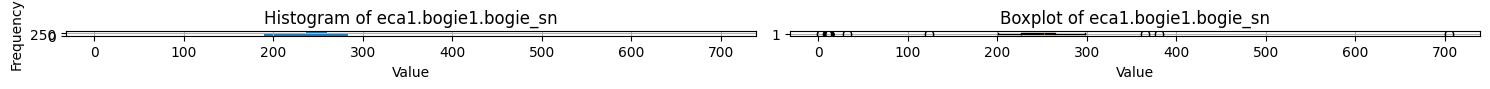

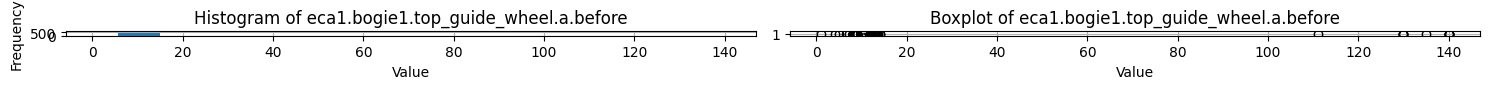

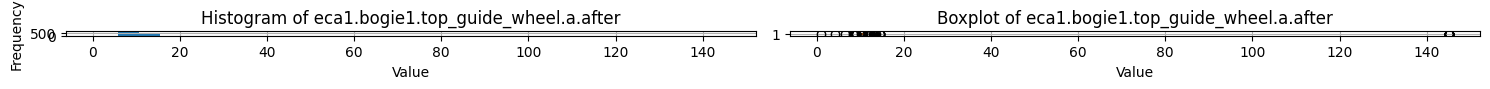

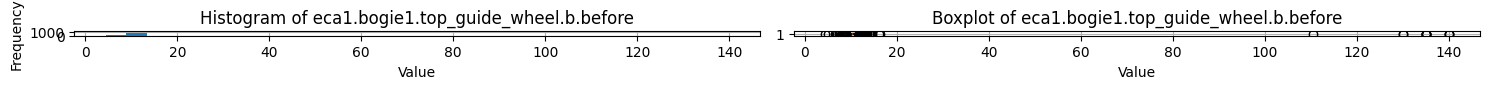

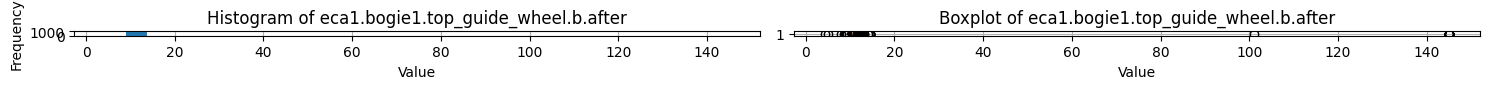

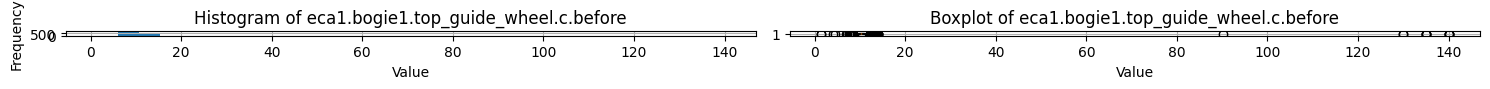

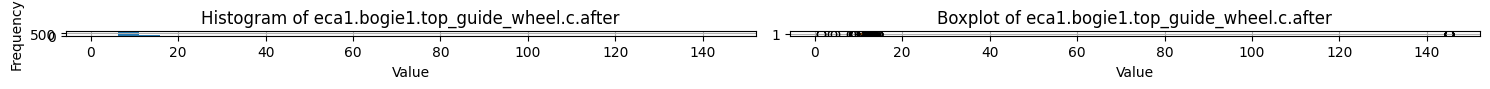

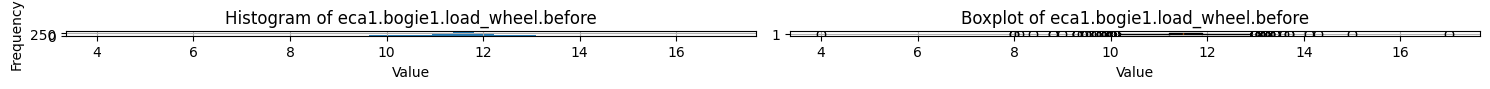

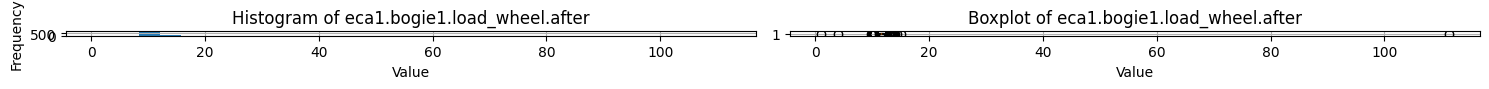

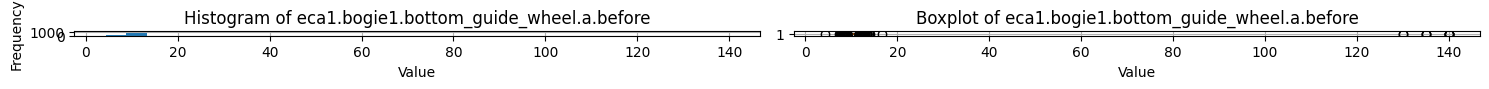

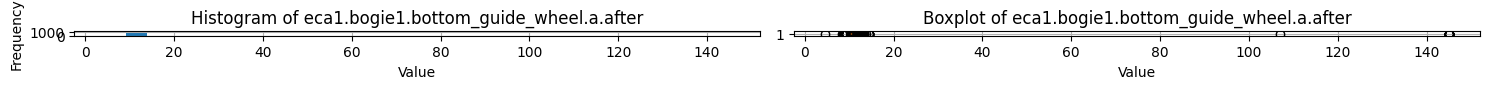

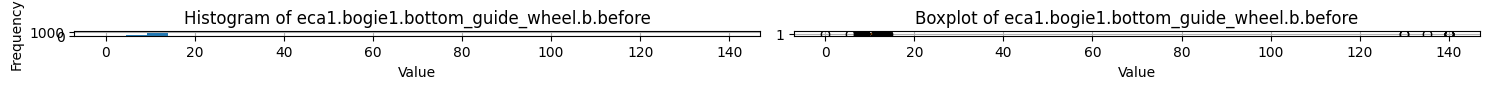

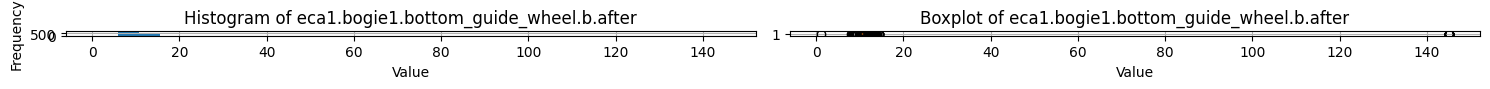

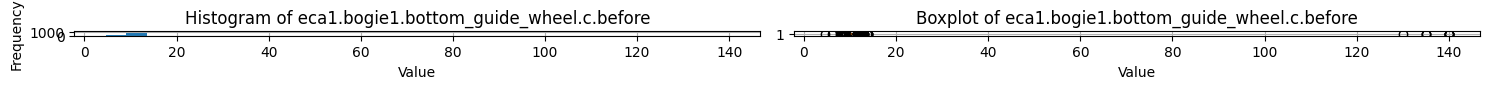

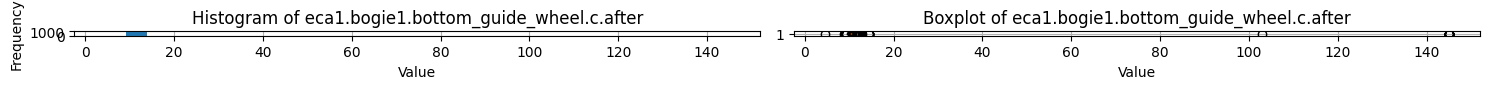

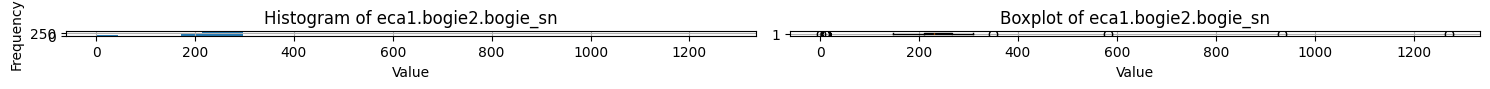

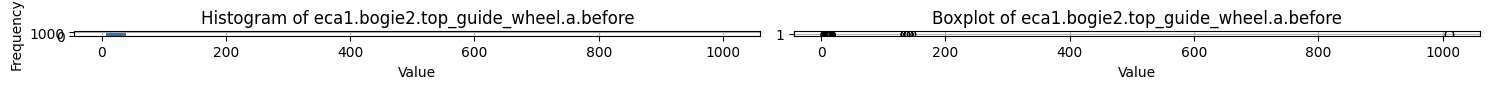

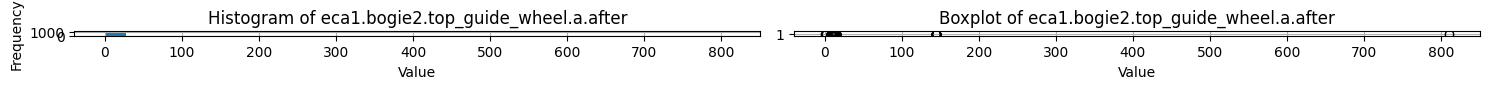

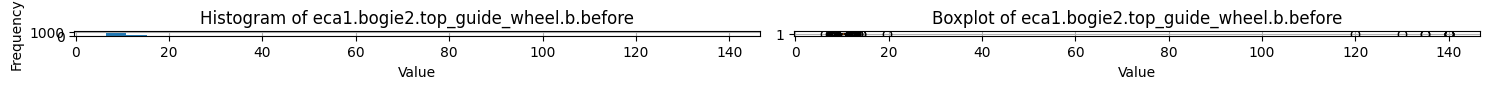

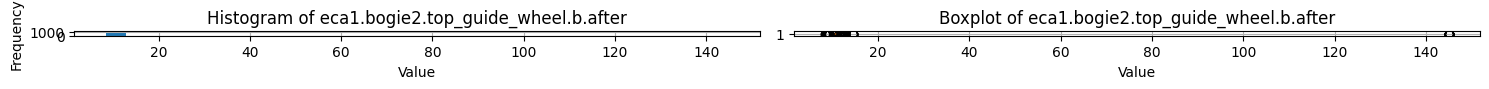

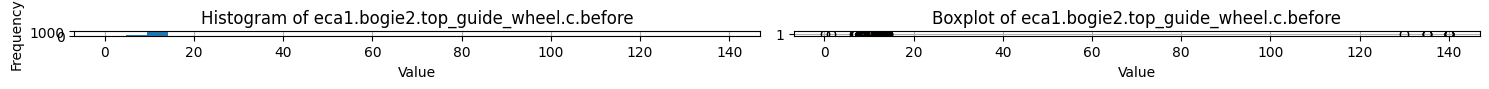

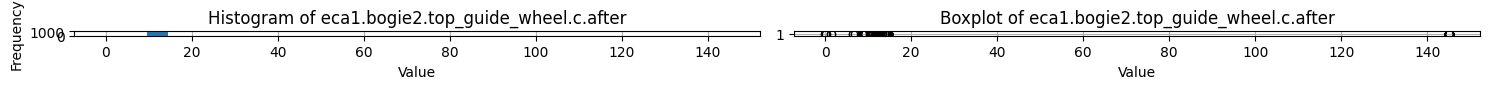

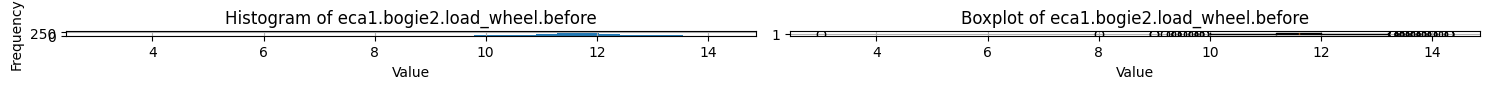

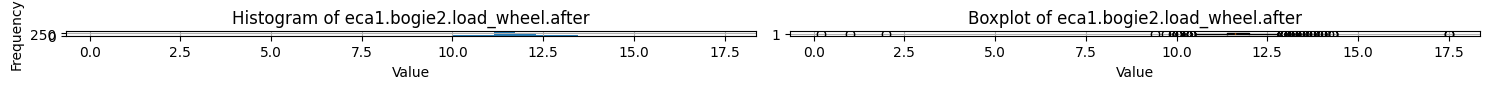

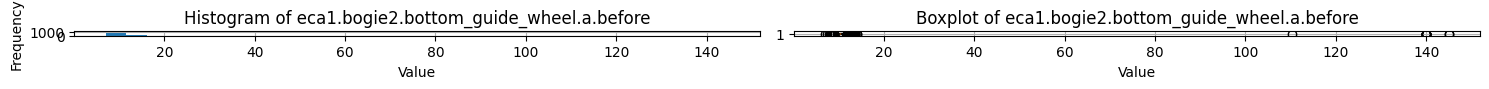

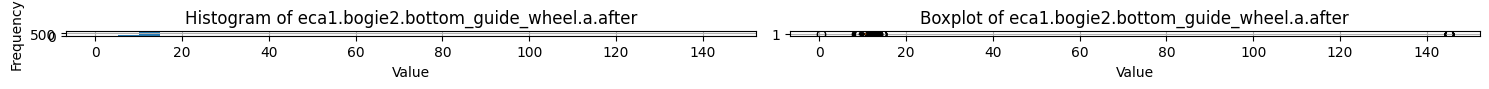

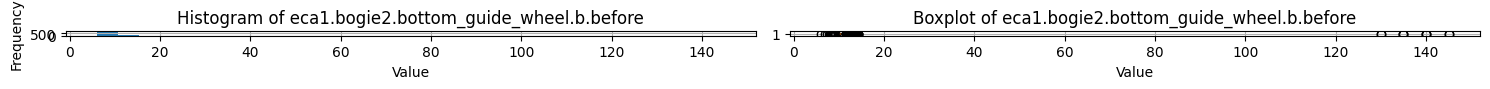

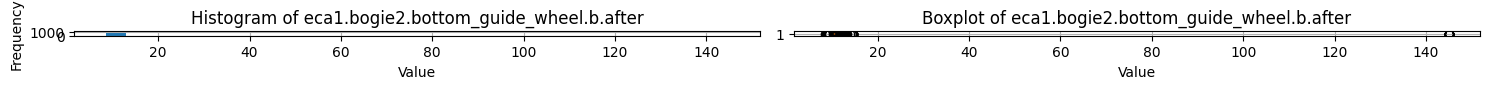

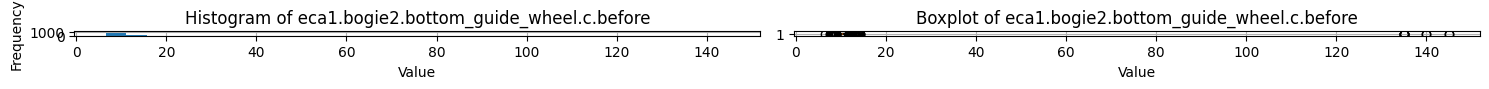

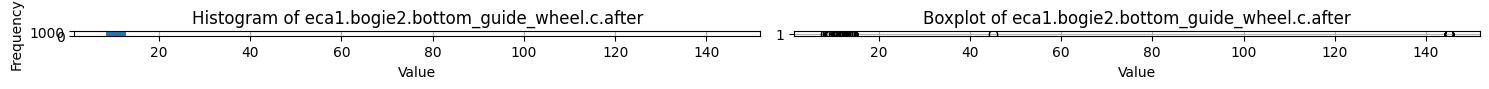

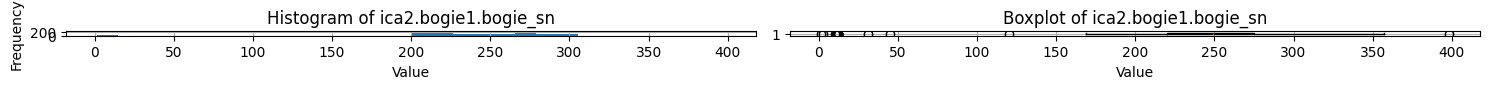

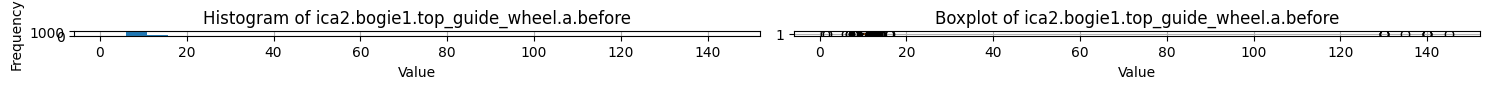

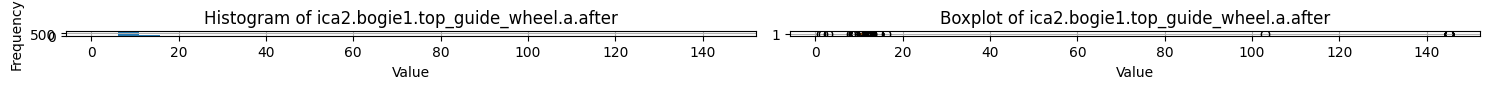

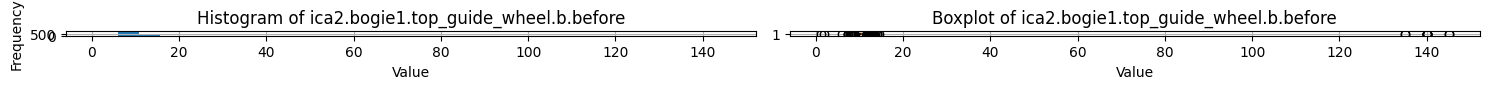

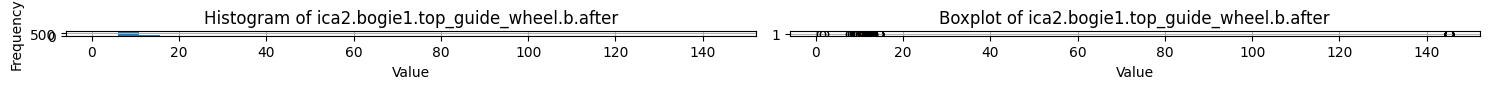

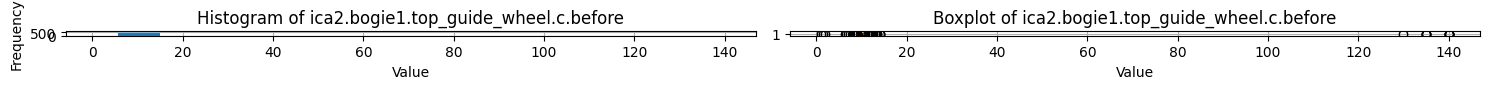

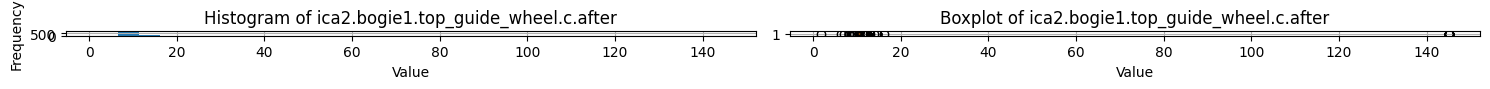

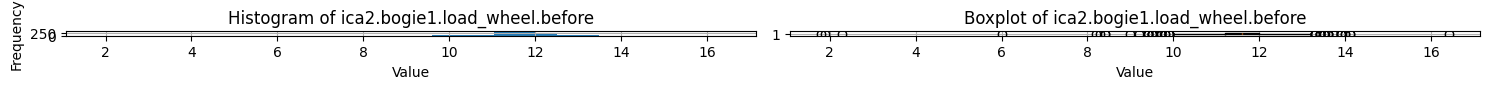

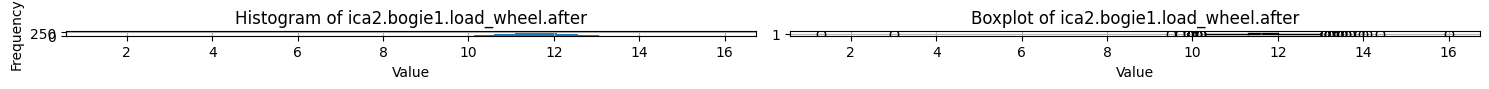

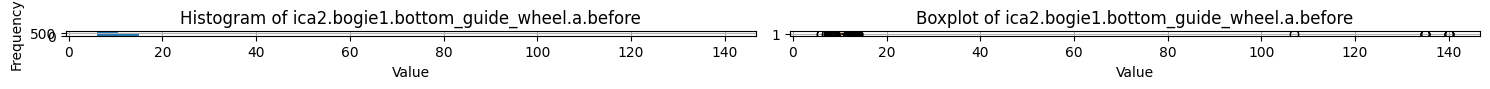

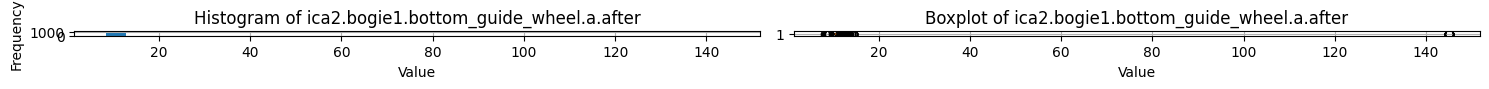

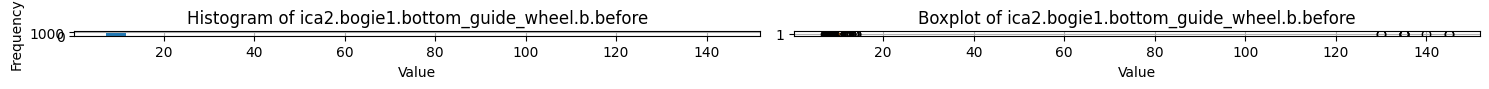

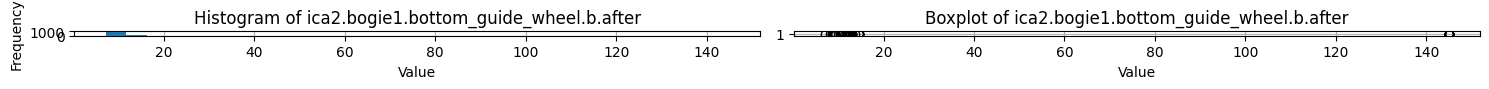

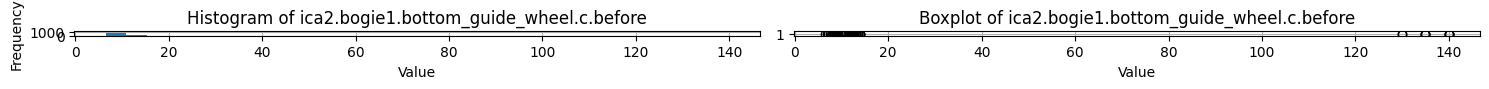

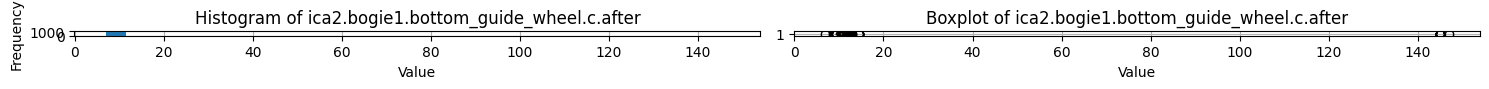

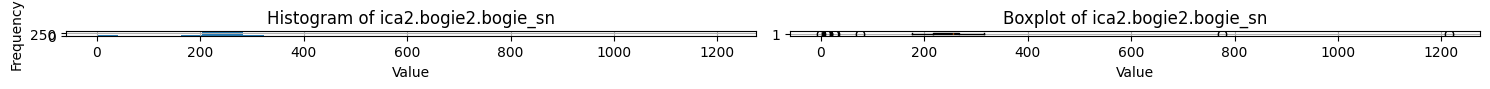

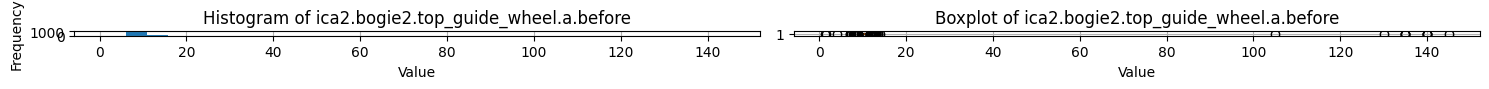

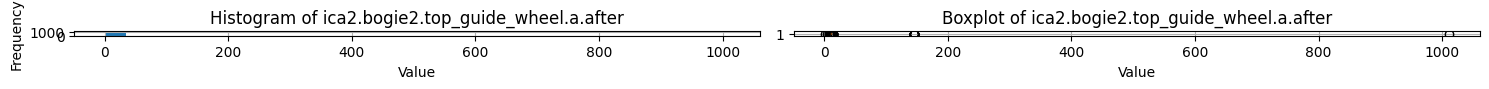

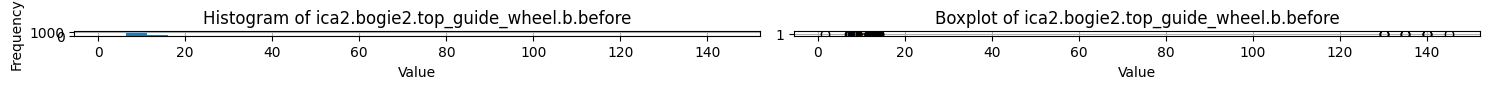

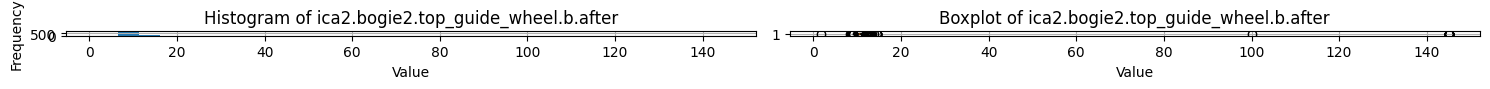

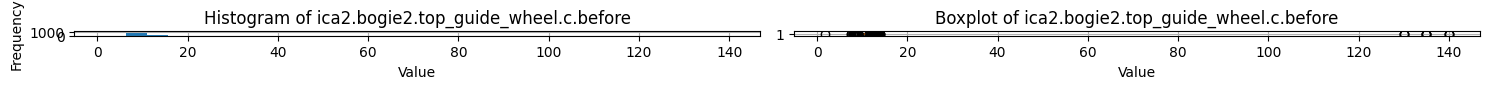

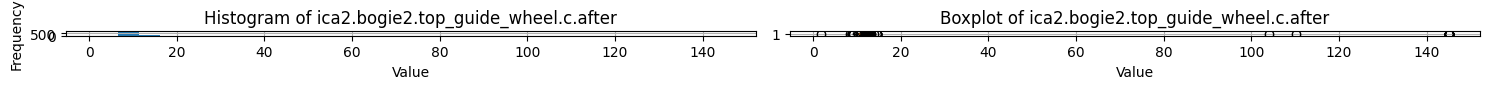

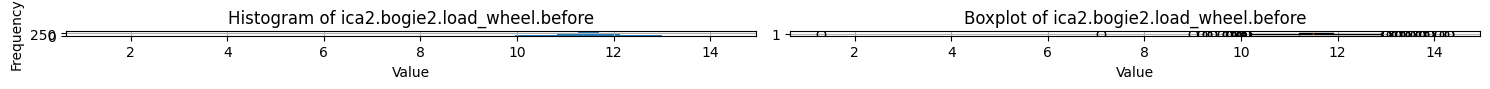

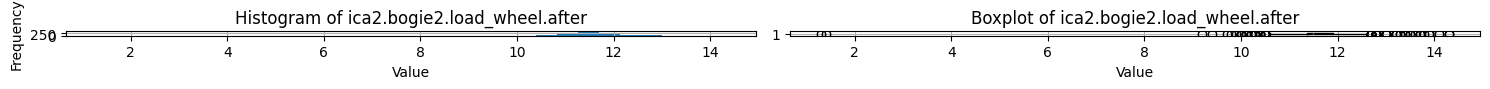

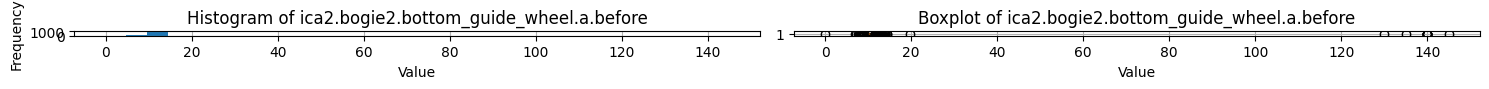

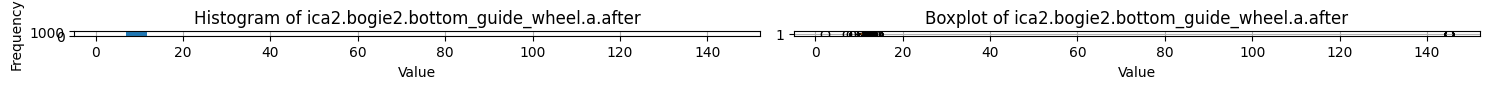

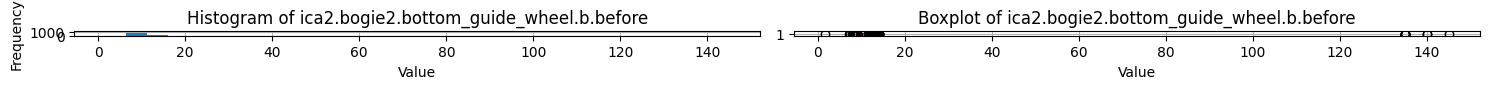

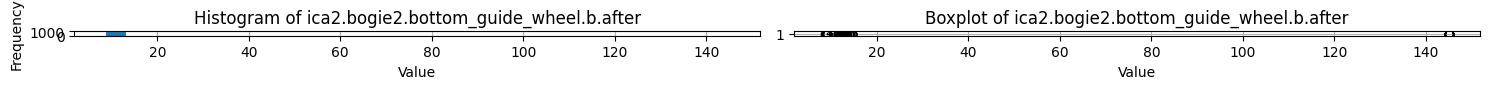

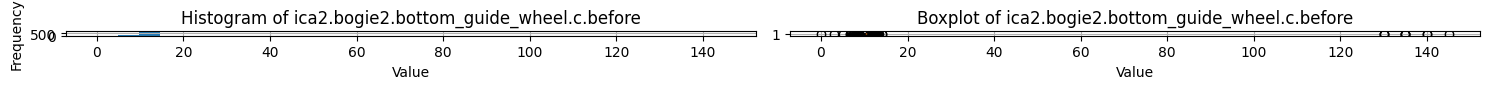

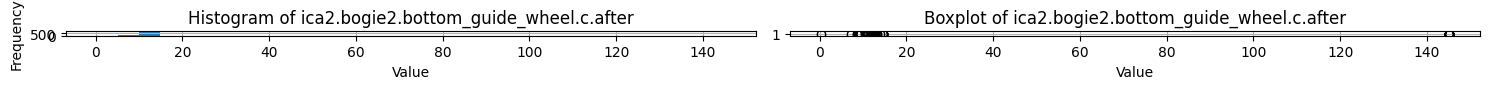

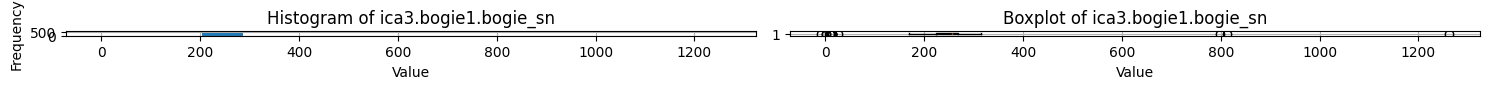

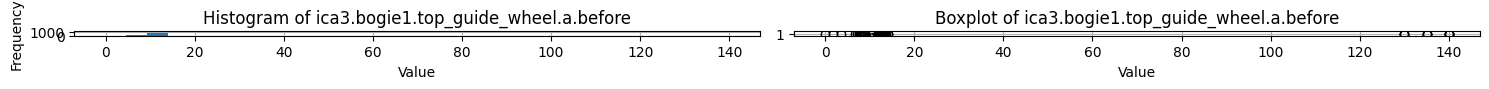

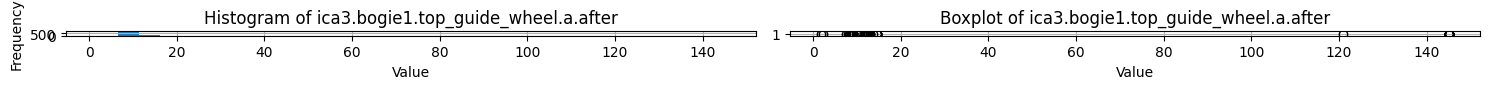

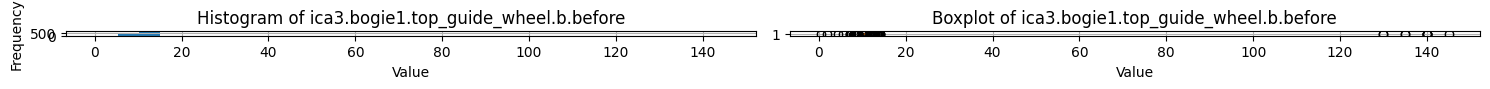

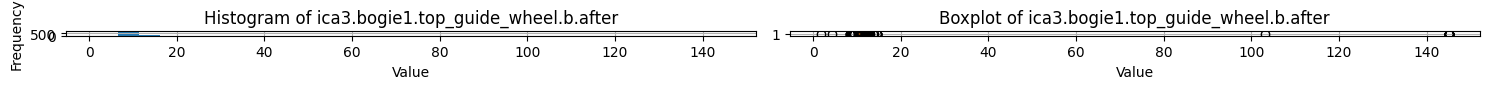

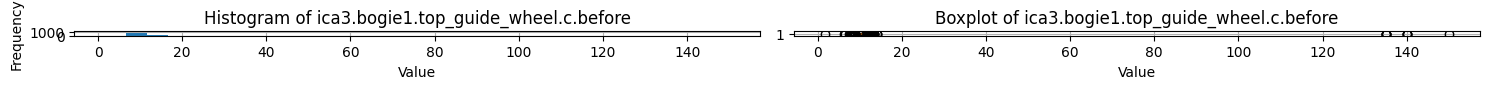

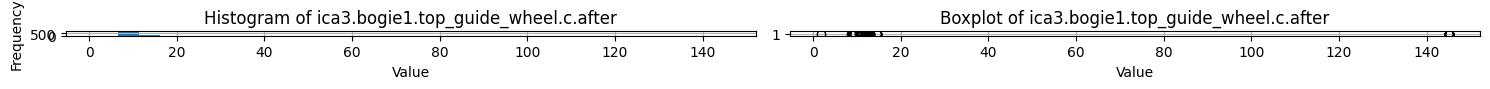

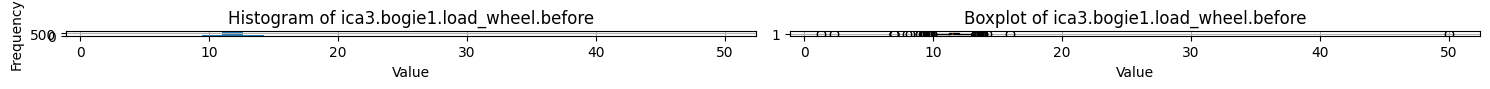

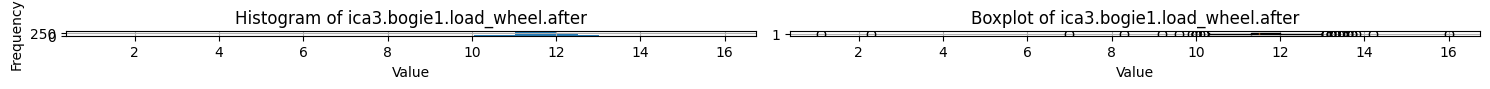

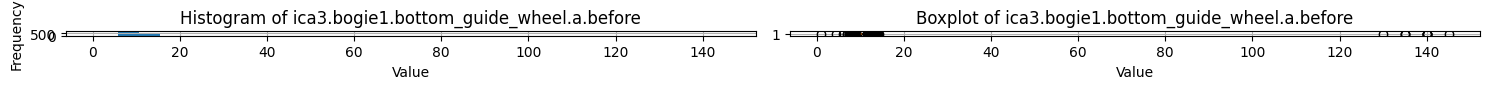

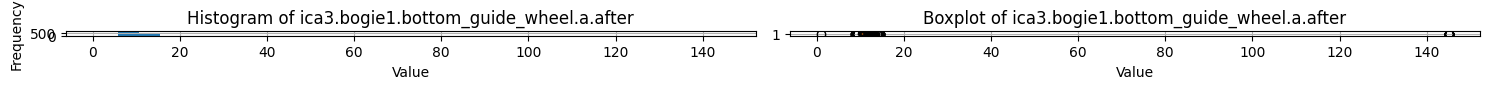

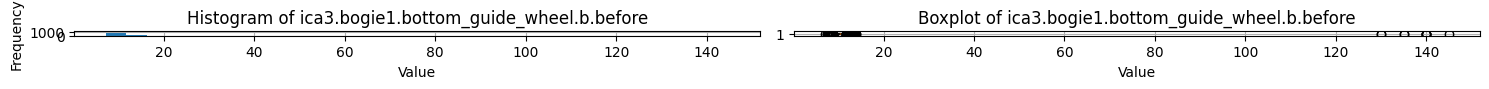

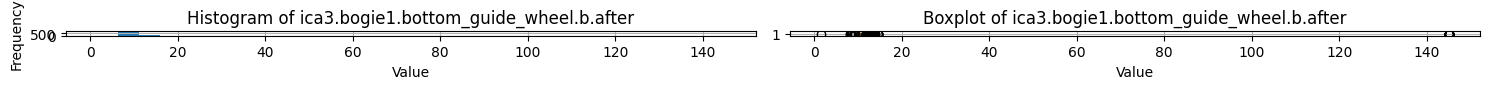

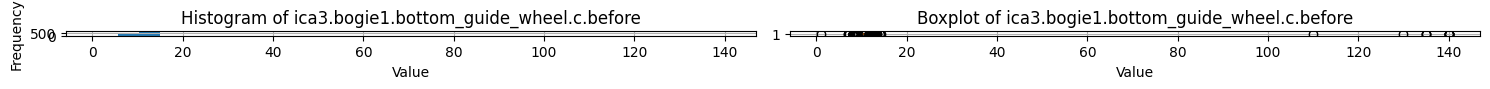

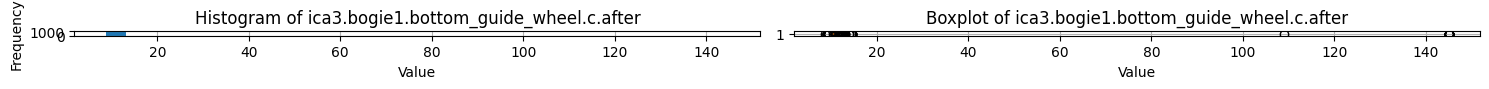

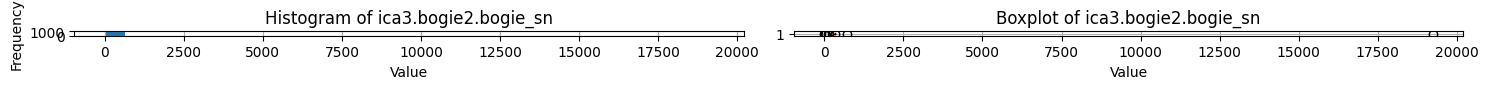

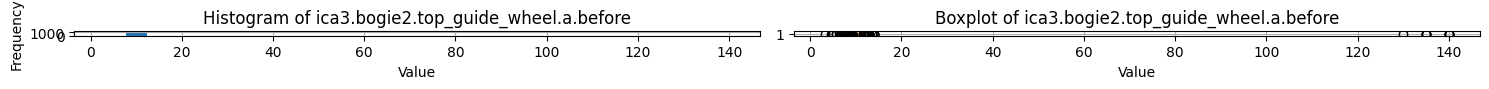

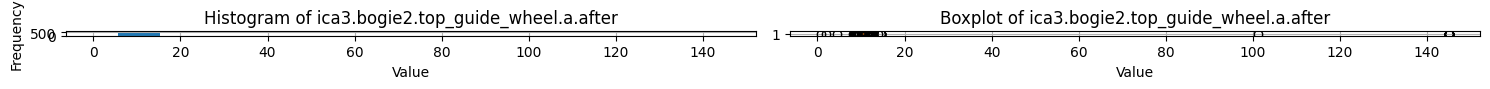

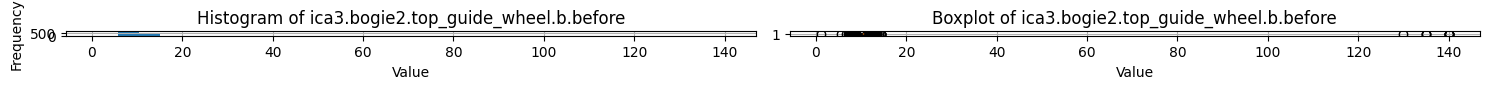

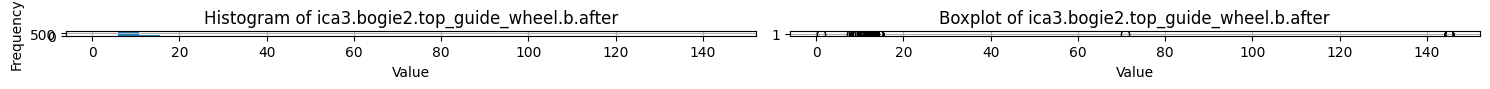

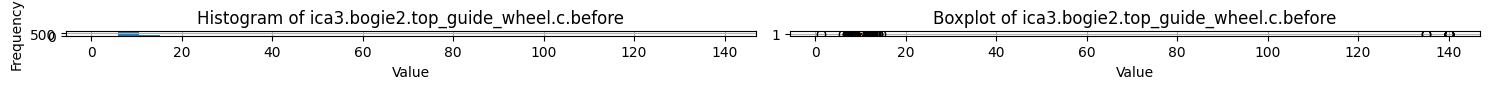

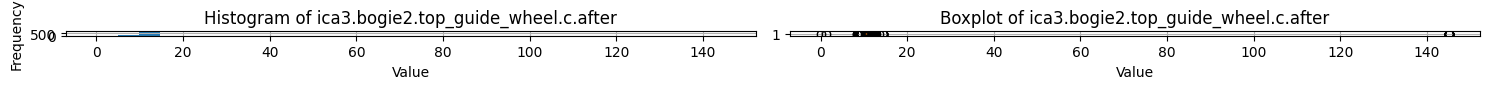

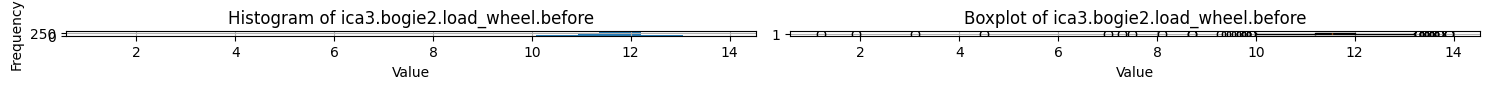

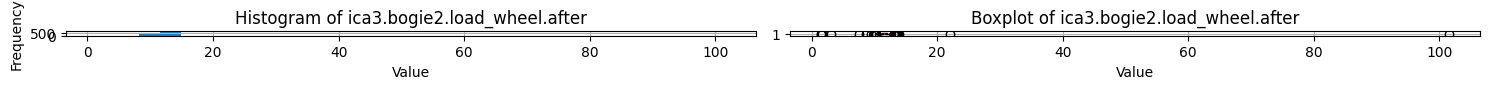

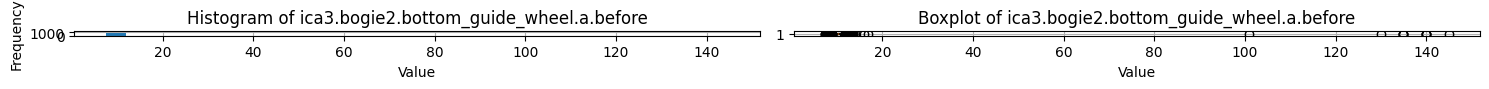

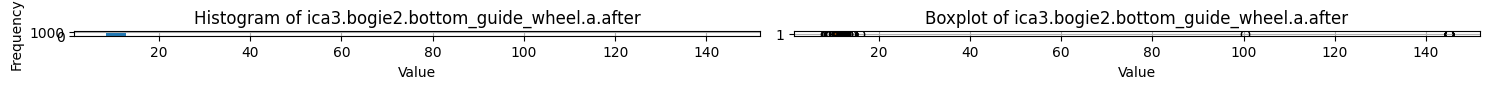

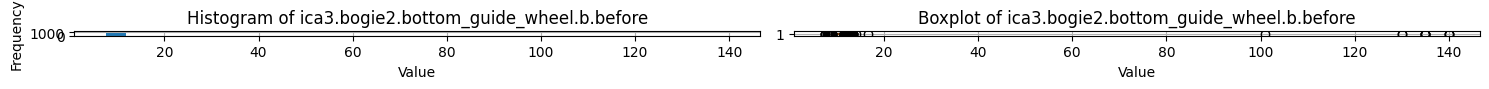

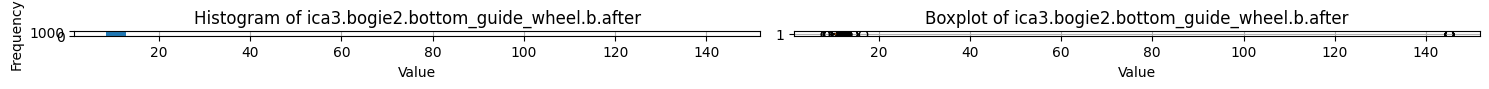

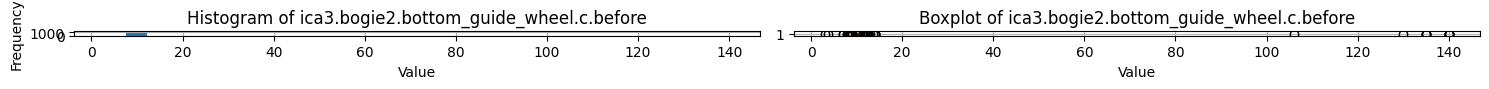

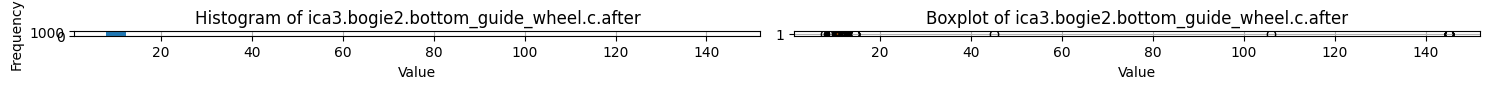

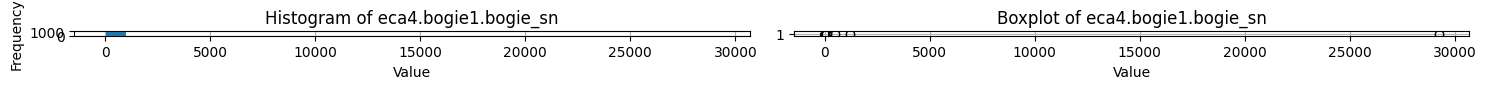

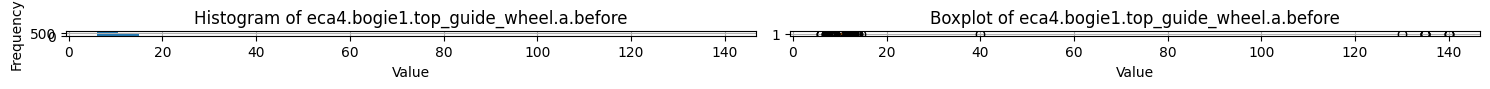

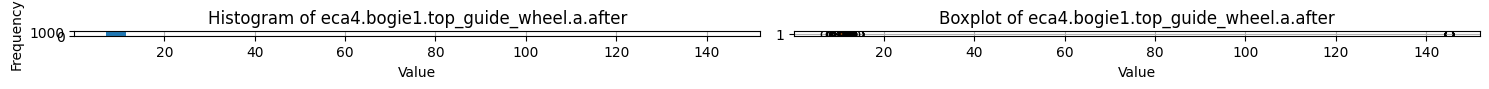

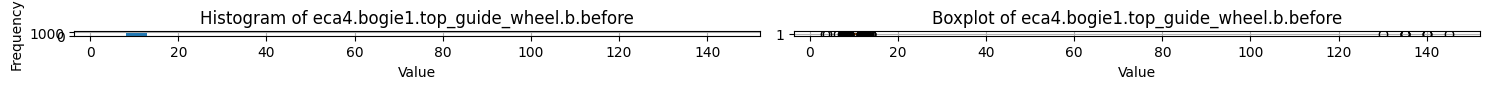

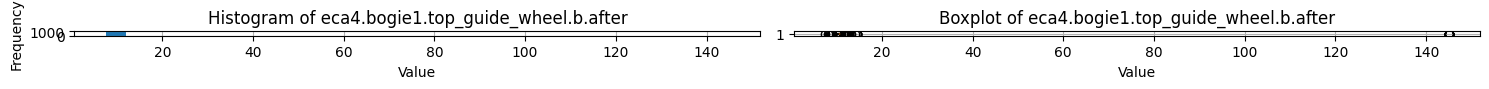

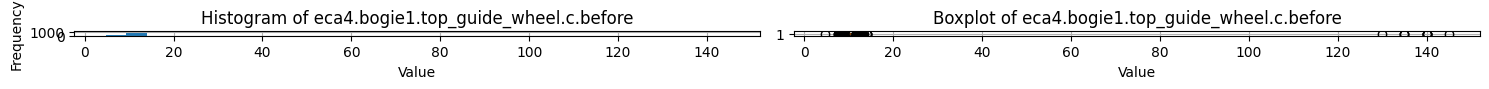

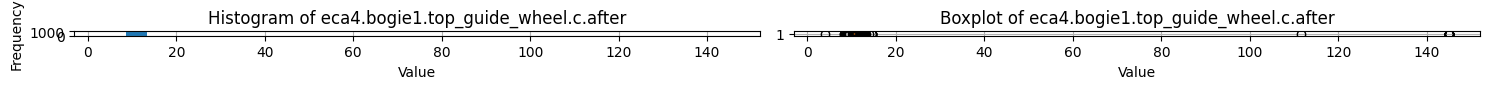

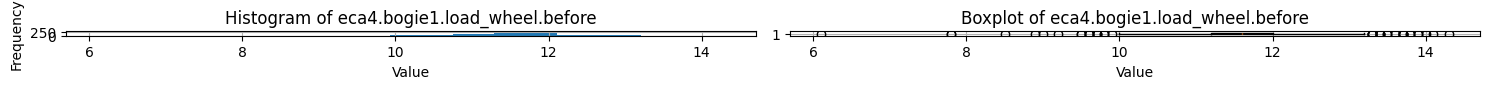

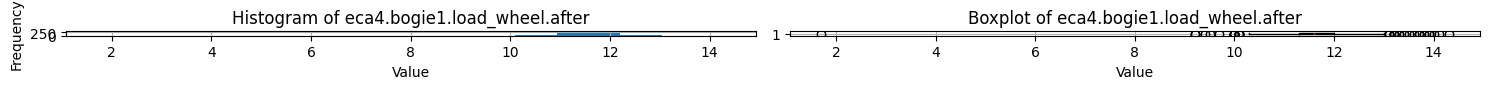

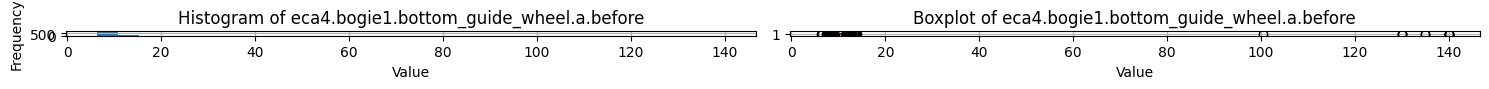

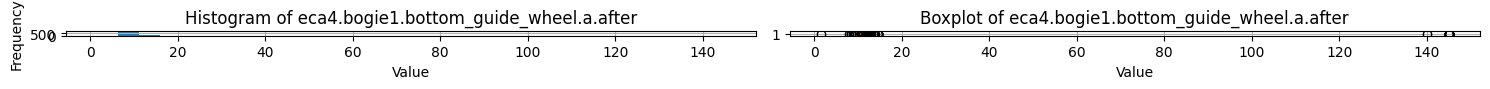

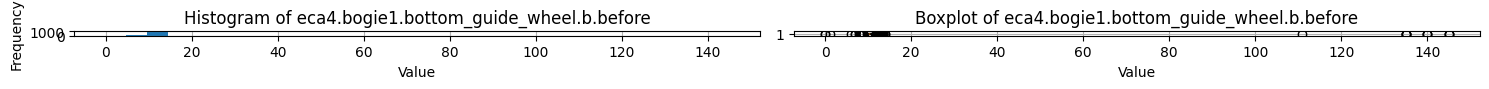

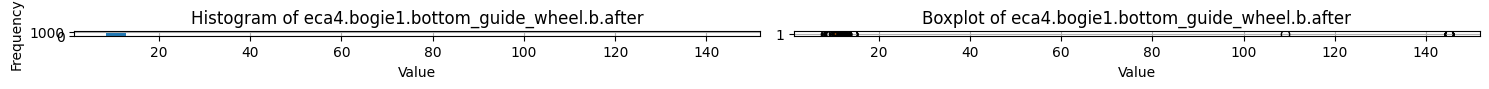

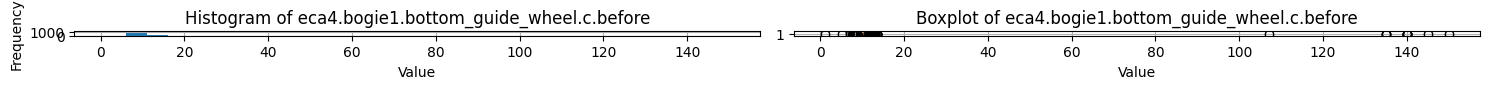

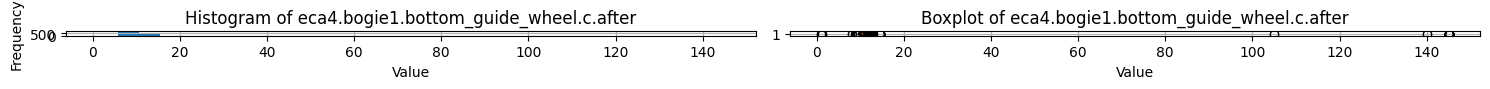

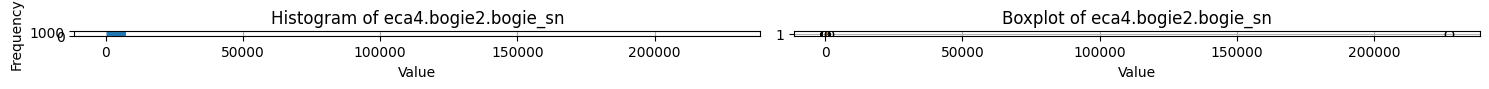

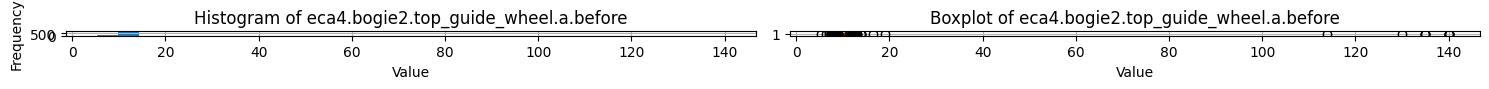

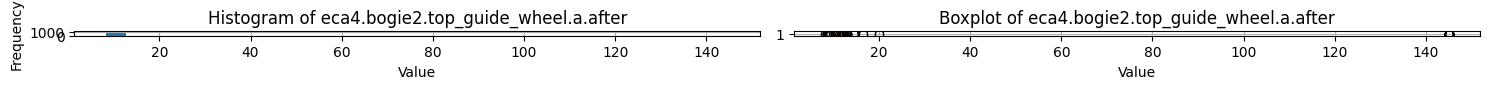

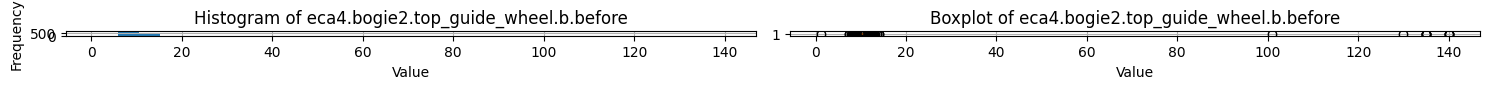

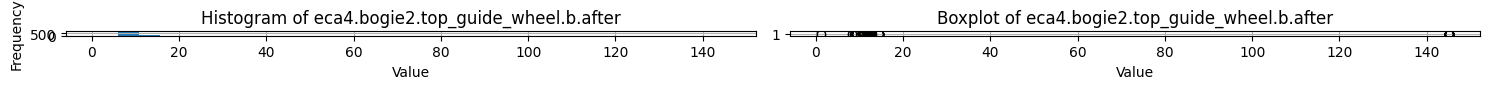

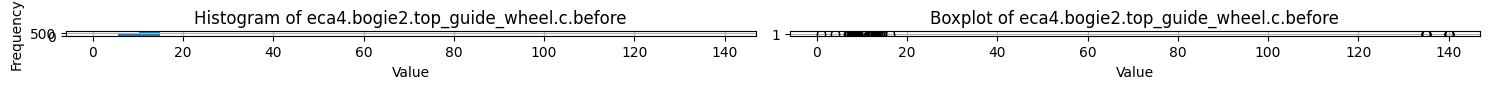

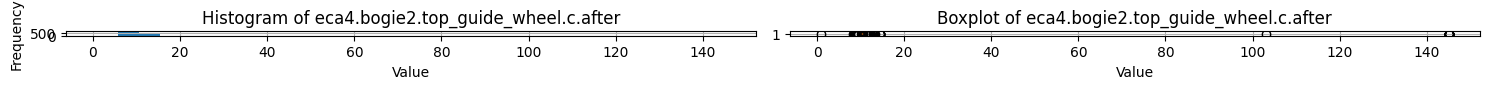

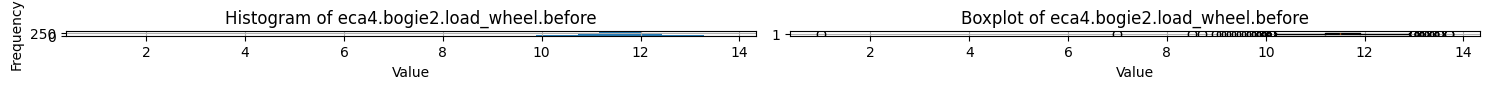

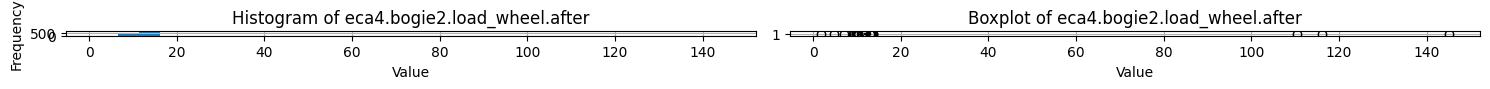

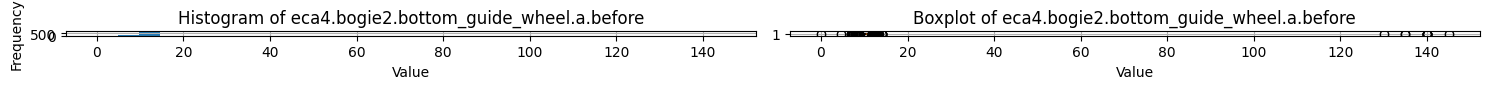

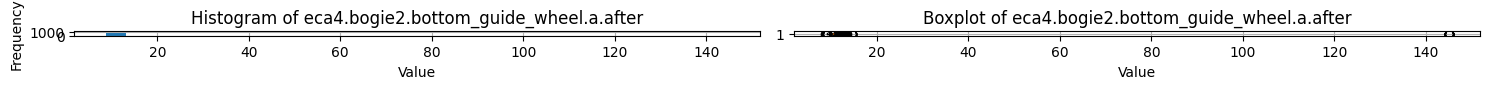

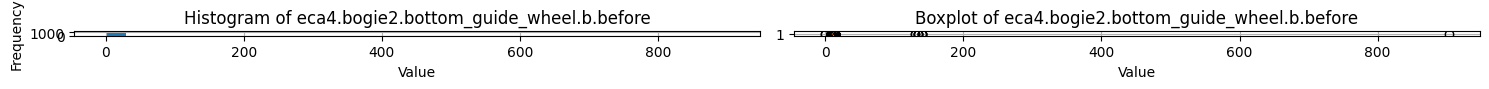

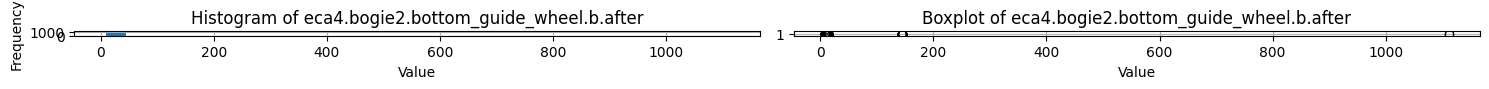

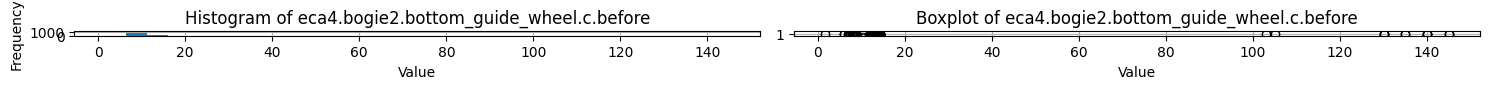

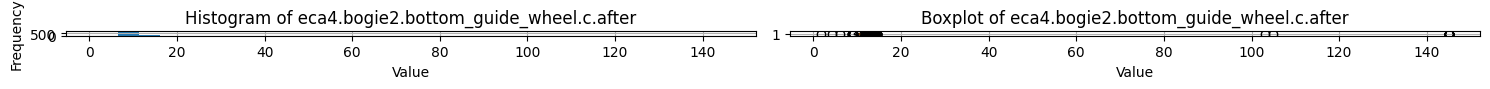

In [32]:
import matplotlib.pyplot as plt

for col in measurement_cols:
    plt.figure(figsize=(15, 1))

    plt.subplot(1, 2, 1)
    plt.hist(tyrepressure_df[col].dropna(), bins=30)
    plt.title(f"Histogram of {col}")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.boxplot(tyrepressure_df[col].dropna(), vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel("Value")
    plt.grid(True)

    plt.tight_layout()
    plt.show()


In [ ]:
output_path = '../../output/rolling_stock.xlsx'

with pd.ExcelWriter(output_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    tyrepressure_df.to_excel(writer, index=False, sheet_name='tyre_pressure')

print(f"✅ Exported successfully to '{output_path}' (replaced existing sheet)")